**Import tools**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap


**Upload dataset**

In [3]:
from google.colab import files
upload_dataset = files.upload()


Saving used_car_dataset.csv to used_car_dataset.csv


**Read dataset**

In [4]:
df = pd.read_csv("used_car_dataset.csv")
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


**Dataset information**

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


,0
make_year,0
mileage_kmpl,0
engine_cc,0
fuel_type,0
owner_count,0
price_usd,0
brand,0
transmission,0
color,0
service_history,2038


**EDA**

Distribution of target variable

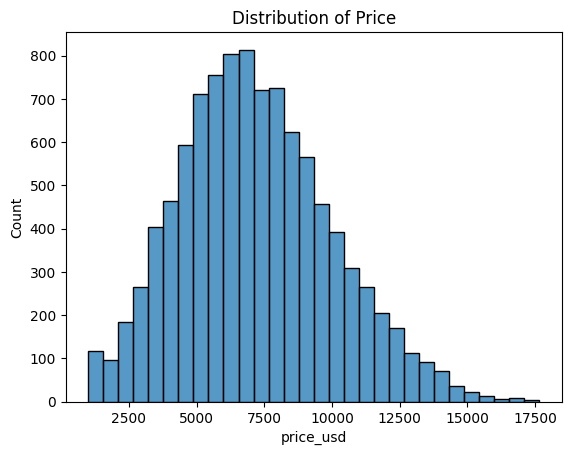

In [6]:
TARGET = "price_usd"
sns.histplot(df[TARGET], bins=30)
plt.title("Distribution of Price")
plt.show()

Distribution of numerical features

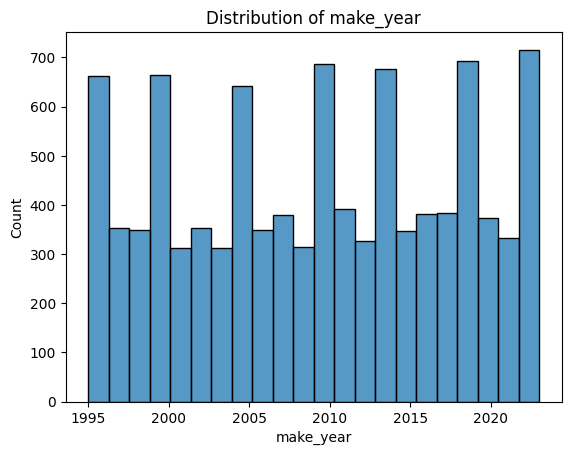

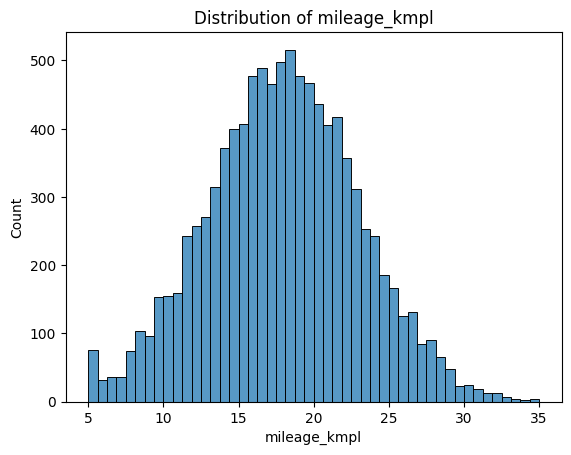

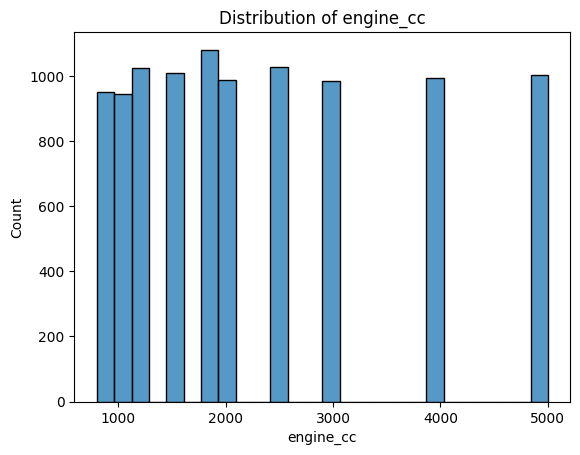

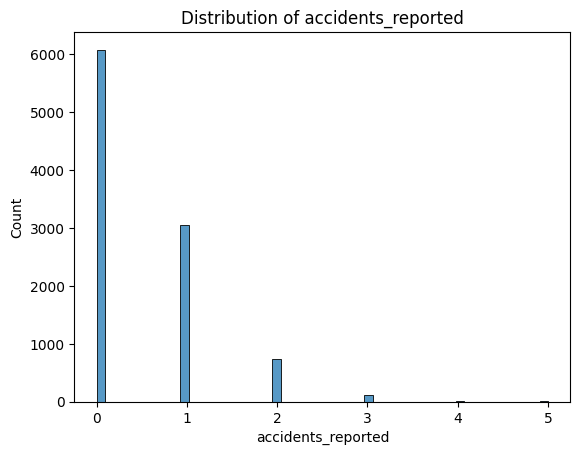

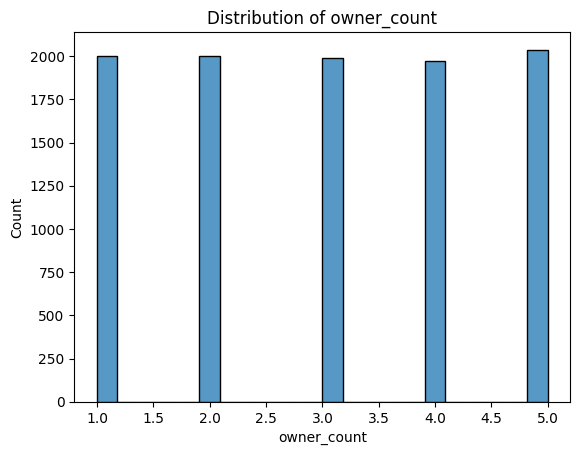

In [7]:
num_cols = ["make_year", "mileage_kmpl", "engine_cc", "accidents_reported", "owner_count"]

for col in num_cols:
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

Distribution of categorical features

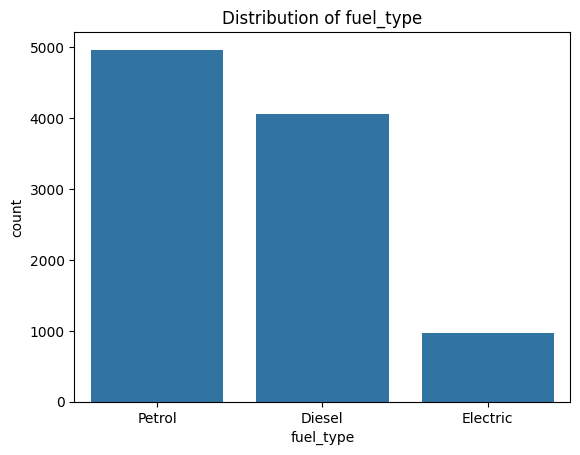

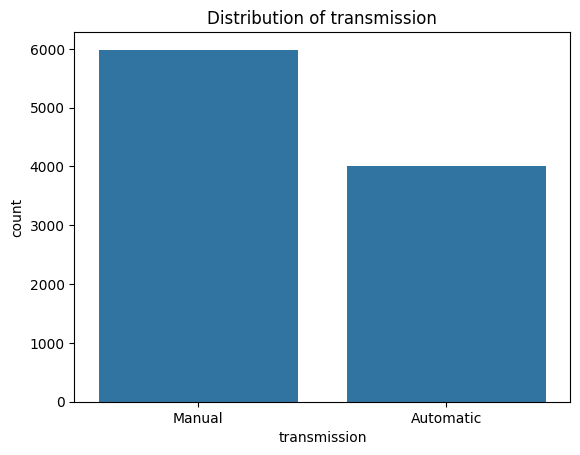

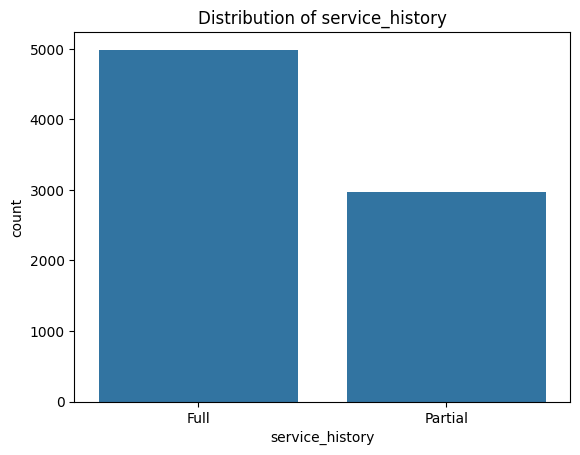

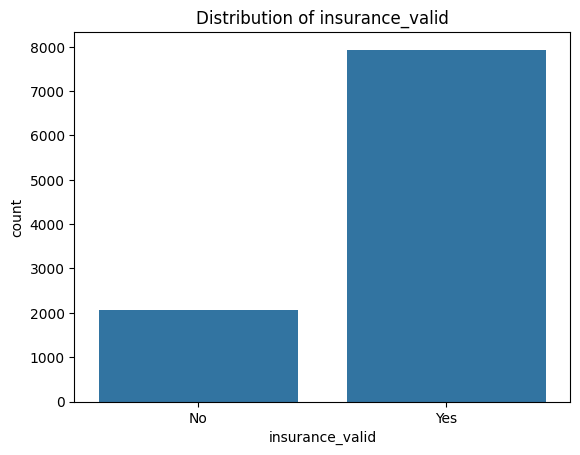

In [8]:
cat_cols = ["fuel_type", "transmission", "service_history", "insurance_valid"]

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()


**Correlation Heatmap**

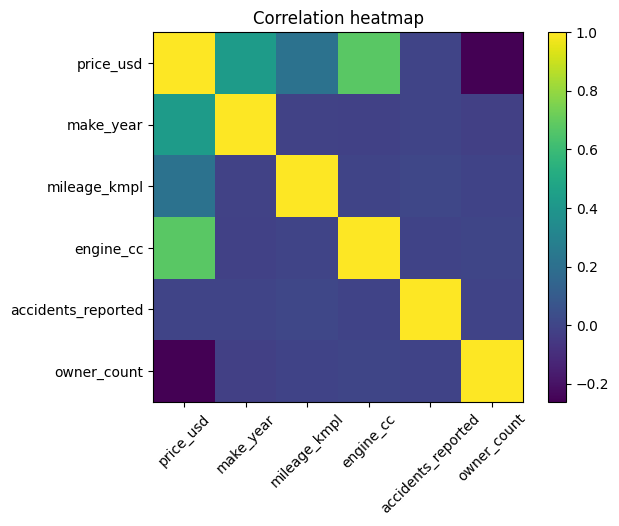

In [9]:
corr = df[[TARGET] + num_cols].corr()
plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.colorbar()
plt.show()


**Data Cleaning**

In [10]:
data = df[[TARGET] + num_cols + cat_cols].copy()

data = data.dropna(subset=["service_history"])

data.head()


After cleaning shape: (7962, 10)


,price_usd,make_year,mileage_kmpl,engine_cc,accidents_reported,owner_count,fuel_type,transmission,service_history,insurance_valid
2,9273.58,2023,18.09,2500,1,5,Diesel,Automatic,Full,Yes
3,6836.24,2009,11.28,800,0,1,Petrol,Manual,Full,Yes
4,4625.79,2005,12.23,1000,0,2,Petrol,Automatic,Full,Yes
5,6856.03,2002,13.77,2500,1,4,Diesel,Manual,Full,Yes
6,6806.77,2023,12.50,1000,0,3,Petrol,Manual,Full,Yes


**Train, Validation and Test Split**

In [11]:
X = data[num_cols + cat_cols]
y = data[TARGET]

# split test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

# split val from trainval (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42)

**One-hot encoding**

In [16]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols)])